In [1]:
import numpy as np
import os
import matplotlib.pyplot as plt
import pickle

In [2]:
LOG_PATH = f"scripts_output"
OUT_PATH = f"outputs"

def elementwise_avg(*mat_list):
    if isinstance(mat_list[0], list):
        mat_list = [np.array(mat) for mat in mat_list]
    size = mat_list[0].shape
    cnt = len(mat_list)
    out = np.zeros(size)
    for mat in mat_list:
        if mat.shape != size:
            print(f"Wrong input: {mat_list[0].shape=}, {mat.shape=}")
        out += mat
    out /= cnt
    return out

def is_number(value):
    flag=True
    try:
        num=float(value)
        flag = num == num
    except ValueError:
        flag=False
    return flag
def load(dataset, seed, epoch, lr, tau, alpha, lmbd, method, fair_metric, eps=None, randinx = False, verbose=2):
    # if dataset == "CIFAR10":
    #     dataset+="(prev)"
    path = f"dataset={dataset}"
    if randinx:
        path+="_randidx"
    if eps is None:
        eps = 0
    # if method != "FSW":
    #     fair_metric = "no_metrics"
    path = os.path.join(path, method)
    path = os.path.join(path, fair_metric)

    # Get log_path
    runs = list()
    for d in os.listdir(os.path.join(LOG_PATH, path)):
        info_dict = dict()
        info_dict['path'] = d
        # print(f"{d=}")
        for elem in d.split("_"):
            k, v = elem.split("=")
            info_dict[k] = int(v) if v.isdigit() else float(v) if is_number(v) else v
            info_dict['path'] = d
        runs.append(info_dict)
    avails = list()
    for run in runs:
        seed_flag = seed == run.get("seed", None)
        epoch_flag = epoch == run.get("epoch", None)
        lr_flag = lr == run.get("lr", None)
        tau_flag = tau == run.get("tau", 0)
        alpha_flag = alpha == run.get("alpha", 0)
        lmbd_flag = lmbd == run.get("lmbd", 0)
        eps_flag = eps == run.get("eps", 0)
        flag = seed_flag & epoch_flag & lr_flag & tau_flag & alpha_flag & lmbd_flag & eps_flag
        if flag:
            avails.append(run)
    
    if len(avails) == 0:
        print("No avails")
        if verbose > 2:
            print(runs)
        return False
    target = avails[0]
    
    log_path = os.path.join(path, target['path'])

    out = os.path.join(os.path.join(LOG_PATH, log_path), "log.out")
    err = os.path.join(os.path.join(LOG_PATH, log_path), "log.err")
    if os.path.exists(err):
        with open(err, "r") as f:
            lines = f.readlines()
        if len(lines) and len(lines) not in [2, 5]:
            print(f"{len(lines)=}")
            if verbose:
                print(f"Error in {err} - error during running")
                for line in lines:
                    print(line)
            return False
    else:
        if verbose:
            print(f"error in {os.path.join(LOG_PATH, path)} - not exists")
        return False
    if os.path.exists(out):
        with open(out, "r") as f:
            lines = f.readlines()
        if len(lines) == 0:
            if verbose:
                print(f"{os.path.join(LOG_PATH, path)} - currently running")
            return False
        
    # Get out_path
    runs = list()
    for d in os.listdir(os.path.join(OUT_PATH, path)):
        info_dict = dict()
        info_dict['path'] = d
        # print(f"{d=}")
        for elem in d.split("_"):
            k, v = elem.split("=")
            info_dict[k] = int(v) if v.isdigit() else float(v) if is_number(v) else v
            info_dict['path'] = d
        runs.append(info_dict)

    avails = list()
    for run in runs:
        seed_flag = seed == run.get("seed", None)
        epoch_flag = epoch == run.get("epoch", None)
        lr_flag = lr == run.get("lr", None)
        tau_flag = tau == run.get("tau", 0)
        alpha_flag = alpha == run.get("alpha", 0)
        lmbd_flag = lmbd == run.get("lmbd", 0)
        eps_flag = eps == run.get("eps", 0)
        flag = seed_flag & epoch_flag & lr_flag & tau_flag & alpha_flag & lmbd_flag & eps_flag
        if flag:
            avails.append(run)
    if len(avails) == 0:
        if verbose > 2:
            print(runs)
        return False
    target = avails[0]
    out_path = os.path.join(path, target['path'])
    return out_path


def load_metrics(path, verbose=0):
    metrics_dir = os.path.join(os.path.join(OUT_PATH, path), "metrics/metrics.pickle")
    try:
        with open(metrics_dir, "rb") as f:
            metric_manager_callback = pickle.load(f)
    except:
        print(f"{path} still running")
        return -1

    if verbose>0:
        print(f"{metric_manager_callback.meters.keys()}")
    return metric_manager_callback

def get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, metric, meter_disp):
    accum = list()
    for seed in seed_range:
        path = load(dataset, seed, epoch, lr, tau, alpha, lmbd, method, metric, randinx=False)
        if not path:
            raise AssertionError
        mmc = load_metrics(path, verbose=False)
        result = mmc.meters[meter_disp].compute_overall()
        accum.append(result)
    return elementwise_avg(*accum)

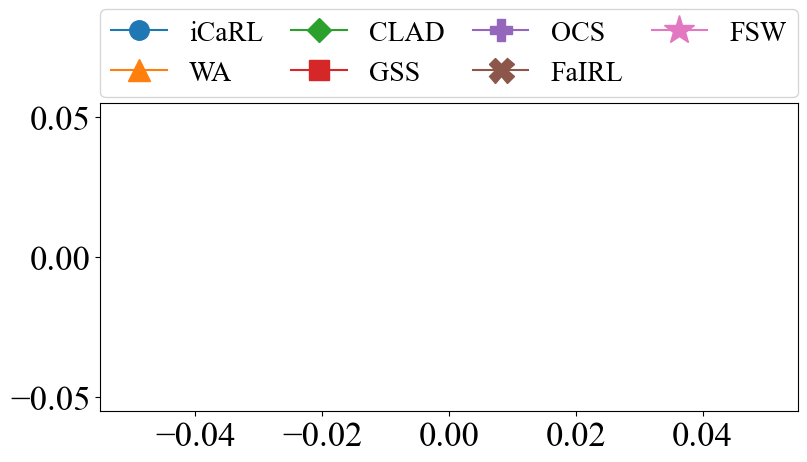

In [3]:
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['pdf.fonttype'] = 42
plt.rc('font', size=25)
plt.rc('axes', labelsize=25)
plt.rc('xtick', labelsize=25)
plt.rc('ytick', labelsize=25)
plt.rc('legend', fontsize=20)
plt.rc('figure', titlesize=25)

# legend
markers = ["o", "^", "D", "s", "P", "X", "*"]
markersize = [3.5, 4, 3, 3.5, 4, 4.5, 5.5]
colors = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6']
labels = ["iCaRL", "WA", "CLAD", "GSS", "OCS", "FaIRL", "FSW"]
plt.figure(figsize=(9,4))

for marker, label, c, ms in zip(markers, labels, colors, markersize):
    plt.plot([], [], marker=marker, label=label, color=c, markersize=ms*4)

plt.legend(bbox_to_anchor=(0., 1.02, 1., .102), loc='lower left',
           ncol=4, mode="expand", borderaxespad=0.)
plt.savefig(f"figs/sequential/legend.pdf", bbox_inches="tight")
plt.savefig(f"figs/sequential/legend.png", bbox_inches="tight")
plt.show()


In [4]:
def draw_plot(avg_data, labels, dataset, ylabel=None, y_range=[0, 1], loc=None, FSW_metric=None):
    if ylabel == "accuracy":
        ylabel_disp = "Accuracy"
        ylabel = "Accuracy"
    else:
        ylabel_disp = ylabel# type: ignore
        ylabel_disp = ylabel_disp + " Disparity" # type: ignore
    markers = ["o", "^", 'D', "s", "P", "X", "*"]
    markersize = [3.5, 4, 3, 3.5, 4, 4.5, 5.5]
    colors = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5', 'C6']
    if len(avg_data) == 6:
        markers = markers[:4]+markers[5:]
        markersize = markersize[:4]+markersize[5:]
        colors = colors[:4]+colors[5:]
    plt.figure(figsize=(6.5, 5))
    plt.rcParams["font.family"] = "Times New Roman"
    plt.rcParams['pdf.fonttype'] = 42
    plt.rc('font', size=25)
    plt.rc('axes', labelsize=25)
    plt.rc('xtick', labelsize=25)
    plt.rc('ytick', labelsize=25)
    plt.xticks(np.arange(1, len(avg_data[0])+1, 1))
    plt.rc('legend', fontsize=20)
    plt.rc('figure', titlesize=25)
    for i, e in enumerate(avg_data):
        plt.plot(np.arange(1, len(e)+1), e, label=labels[i], marker=markers[i], color = colors[i],markersize=markersize[i]*2)
    plt.ylim(y_range)
    plt.xlabel('Number of tasks')
    plt.ylabel(ylabel_disp)
    
    plt.savefig(f"figs/sequential/{dataset}_{ylabel}.pdf", bbox_inches="tight")
    plt.show()

    
    # plt.clf()

In [5]:
save_accuracy = False
"""
True: show/save accuracy plot
False: show/save fairness metric plot
"""

'\nTrue: show/save accuracy plot\nFalse: show/save fairness metric plot\n'

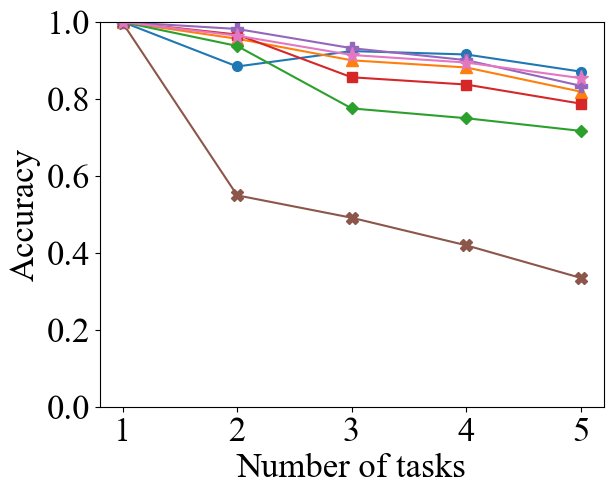

In [ ]:
avg_data = list()
labels = list()

seed_range = [0, 1, 2, 3, 4]
epoch = 5
dataset = "MNIST"
FSW_metric = "EER"

# Modifier
target_metric = "accuracy" # EER, accuracy
if save_accuracy:
    target_metric = "accuracy"
y_range = [0, 1]
if target_metric != "accuracy":
    y_range = [0, .6]
loc = None

metric = "no_metrics"
# 0
method = "iCaRL"
lr = 0.1
tau = 1.0
alpha = 0.0
lmbd = 0.0

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, metric, target_metric))
labels.append(method)

# 1
method = "WA"
lr = 0.01
tau = 1.0
alpha = 0.0
lmbd = 0.0

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, metric, target_metric))
labels.append(method)

# 2
method = "CLAD_1.0"
lr = 0.001
tau = 1.0
alpha = 0.0
lmbd = 0.0

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, metric, target_metric))
labels.append(method)

# 3
method = "GSS"
lr = 0.001
tau = 10.0
alpha = 0.0
lmbd = 0.0

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, metric, target_metric))
labels.append(method)

# 4
method = "OCS"
lr = 0.001
tau = 10.0
alpha = 0.0
lmbd = 0.0

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, metric, target_metric))
labels.append(method)

# 5
method = "FaIRL"
lr = 0.001
tau = 0.0
alpha = 0.0
lmbd = 0.0

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, metric, target_metric))
labels.append(method)


# 6
method = "FSW"
lr = 0.001
tau = 10.0
alpha = 0.001
lmbd = 1.0

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, FSW_metric, target_metric))
labels.append(method)



draw_plot(avg_data, labels, dataset, ylabel=target_metric, y_range=y_range, loc=loc)

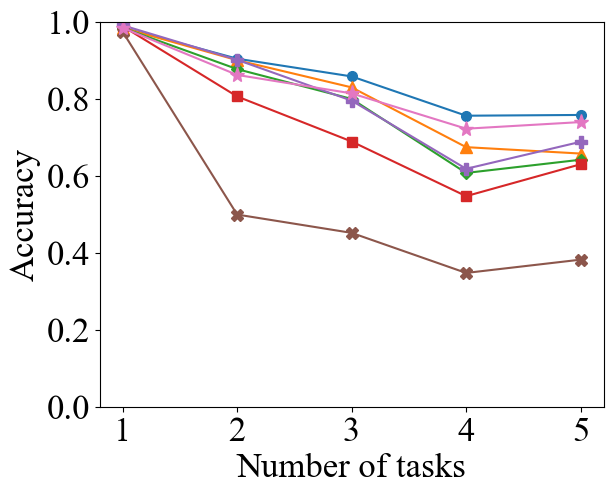

In [ ]:
avg_data = list()
labels = list()

seed_range = [0, 1, 2, 3, 4]
epoch = 5
dataset = "FashionMNIST"
FSW_metric = "EER"

# Modifier
target_metric = "accuracy" # EER, accuracy
if save_accuracy:
    target_metric = "accuracy"
y_range = [0, 1]
if target_metric != "accuracy":
    y_range = [0, .6]
loc = None


metric = "no_metrics"
# 0
method = "iCaRL"
lr = 0.01
tau = 1.0
alpha = 0.0
lmbd = 0.0

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, metric, target_metric))
labels.append(method)

# 1
method = "WA"
lr = 0.001
tau = 1.0
alpha = 0.0
lmbd = 0.0

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, metric, target_metric))
labels.append(method)

# 2
method = "CLAD_1.0"
lr = 0.001
tau = 1.0
alpha = 0.0
lmbd = 0.0

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, metric, target_metric))
labels.append(method)

# 3
method = "GSS"
lr = 0.001
tau = 5.0
alpha = 0.0
lmbd = 0.0

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, metric, target_metric))
labels.append(method)

# 4
method = "OCS"
lr = 0.01
tau = 10.0
alpha = 0.0
lmbd = 0.0

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, metric, target_metric))
labels.append(method)

# 4
method = "FaIRL"
lr = 0.01
tau = 0.0
alpha = 0.0
lmbd = 0.0

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, metric, target_metric))
labels.append(method)


# 5
method = "FSW"
lr = 0.001
tau = 10.0
alpha = 0.001
lmbd = 0.1

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, FSW_metric, target_metric))
labels.append(method)



draw_plot(avg_data, labels, dataset, ylabel=target_metric, y_range=y_range, loc=loc)

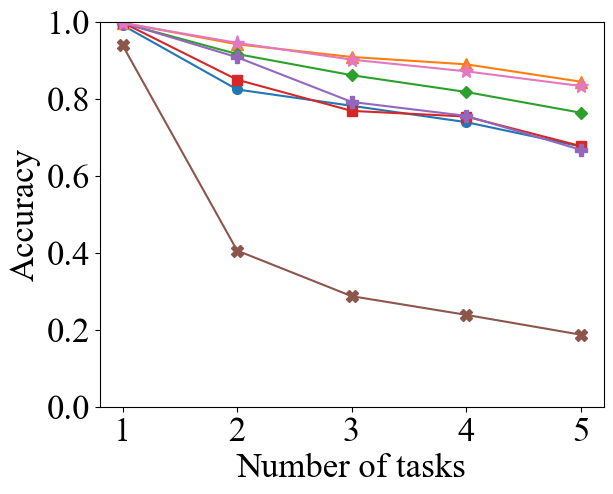

In [8]:
avg_data = list()
labels = list()

seed_range = [0, 1, 2, 3, 4]
epoch = 15
dataset = "BiasedMNIST"
FSW_metric = "EO"

# Modifier
target_metric = "accuracy" # EO, accuracy
if save_accuracy:
    target_metric = "accuracy"
y_range = [0, 1]
if target_metric != "accuracy":
    y_range = [0, .7]
loc = None

metric = "no_metrics"
# 0
method = "iCaRL"
lr = 0.1
tau = 1.0
alpha = 0.0
lmbd = 0.0

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, metric, target_metric))
labels.append(method)

# 1
method = "WA"
lr = 0.01
tau = 1.0
alpha = 0.0
lmbd = 0.0

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, metric, target_metric))
labels.append(method)

# 2
method = "CLAD_1.0"
lr = 0.001
tau = 1.0
alpha = 0.0
lmbd = 0.0

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, metric, target_metric))
labels.append(method)

# 3
method = "GSS"
lr = 0.001
tau = 5.0
alpha = 0.0
lmbd = 0.0

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, metric, target_metric))
labels.append(method)

# 4
method = "OCS"
lr = 0.001
tau = 10.0
alpha = 0.0
lmbd = 0.0

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, metric, target_metric))
labels.append(method)

# 5
method = "FaIRL"
lr = 0.01
tau = 0.0
alpha = 0.0
lmbd = 0.0

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, metric, target_metric))
labels.append(method)


# 6
method = "FSW"
lr = 0.001
tau = 10.0
alpha = 0.0005
lmbd = 0.5

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, FSW_metric, target_metric))
labels.append(method)



draw_plot(avg_data, labels, f"{dataset}({FSW_metric})", ylabel=target_metric, y_range=y_range, loc=loc)

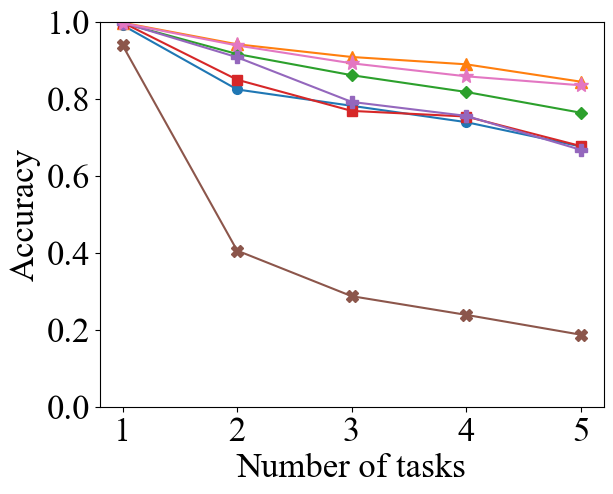

In [9]:
avg_data = list()
labels = list()

seed_range = [0, 1, 2, 3, 4]
epoch = 15
dataset = "BiasedMNIST"
FSW_metric = "DP"

# Modifier
target_metric = "accuracy" # DP, accuracy
if save_accuracy:
    target_metric = "accuracy"
y_range = [0, 1]
if target_metric != "accuracy":
    y_range = [0, .08]
loc = None

metric = "no_metrics"
# 0
method = "iCaRL"
lr = 0.1
tau = 1.0
alpha = 0.0
lmbd = 0.0

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, metric, target_metric))
labels.append(method)

# 1
method = "WA"
lr = 0.01
tau = 1.0
alpha = 0.0
lmbd = 0.0

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, metric, target_metric))
labels.append(method)

# 2
method = "CLAD_1.0"
lr = 0.001
tau = 1.0
alpha = 0.0
lmbd = 0.0

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, metric, target_metric))
labels.append(method)

# 3
method = "GSS"
lr = 0.001
tau = 5.0
alpha = 0.0
lmbd = 0.0

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, metric, target_metric))
labels.append(method)

# 4
method = "OCS"
lr = 0.001
tau = 10.0
alpha = 0.0
lmbd = 0.0

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, metric, target_metric))
labels.append(method)

# 5
method = "FaIRL"
lr = 0.01
tau = 0.0
alpha = 0.0
lmbd = 0.0

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, metric, target_metric))
labels.append(method)

# 6
method = "FSW"
lr = 0.001
tau = 10.0
alpha = 0.002
lmbd = 0.1

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, FSW_metric, target_metric))
labels.append(method)



draw_plot(avg_data, labels, f"{dataset}({FSW_metric})", ylabel=target_metric, y_range=y_range, loc=loc)

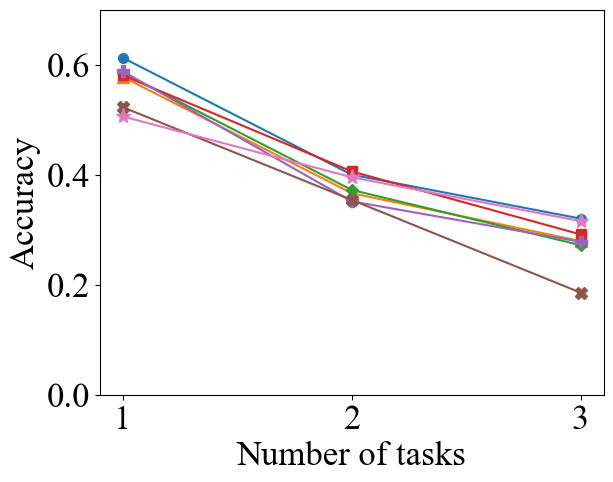

In [10]:
avg_data = list()
labels = list()

seed_range = [0, 1, 2, 3, 4]
epoch = 25
dataset = "Drug"
FSW_metric = "EO"

# Modifier
target_metric = "accuracy" # EO, accuracy
if save_accuracy:
    target_metric = "accuracy"
y_range = [0, .7]
if target_metric != "accuracy":
    y_range = [0, .3]
loc = None

metric = "no_metrics"
# 0
method = "iCaRL"
lr = 0.001
tau = 1.0
alpha = 0.0
lmbd = 0.0

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, metric, target_metric))
labels.append(method)

# 1
method = "WA"
lr = 0.1
tau = 1.0
alpha = 0.0
lmbd = 0.0

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, metric, target_metric))
labels.append(method)

# 2
method = "CLAD_1.0"
lr = 0.01
tau = 1.0
alpha = 0.0
lmbd = 0.0

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, metric, target_metric))
labels.append(method)

# 3
method = "GSS"
lr = 0.001
tau = 5.0
alpha = 0.0
lmbd = 0.0

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, metric, target_metric))
labels.append(method)

# 4
method = "OCS"
lr = 0.01
tau = 5.0
alpha = 0.0
lmbd = 0.0

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, metric, target_metric))
labels.append(method)

# 5
method = "FaIRL"
lr = 0.01
tau = 0.0
alpha = 0.0
lmbd = 0.0

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, metric, target_metric))
labels.append(method)

# 6
method = "FSW"
lr = 0.001
tau = 1.0
alpha = 0.002
lmbd = 0.1

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, FSW_metric, target_metric))
labels.append(method)



draw_plot(avg_data, labels, f"{dataset}({FSW_metric})", ylabel=target_metric, y_range=y_range, loc=loc)

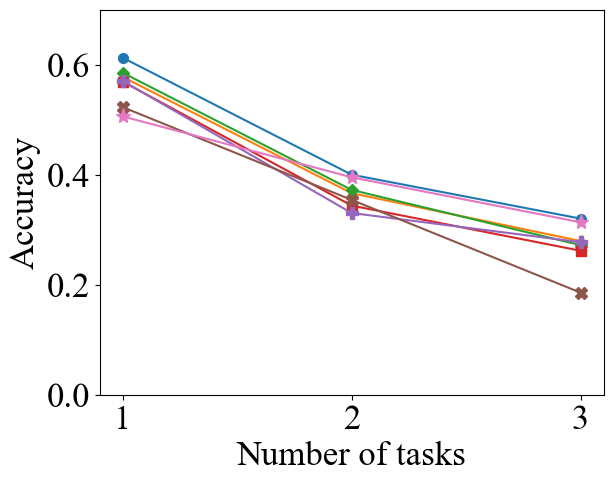

In [11]:
avg_data = list()
labels = list()

seed_range = [0, 1, 2, 3, 4]
epoch = 25
dataset = "Drug"
FSW_metric = "DP"

# Modifier
target_metric = "accuracy" # DP, accuracy
if save_accuracy:
    target_metric = "accuracy"
y_range = [0, .7]
if target_metric != "accuracy":
    y_range = [0, .2]
loc = None

metric = "no_metrics"
# 0
method = "iCaRL"
lr = 0.001
tau = 1.0
alpha = 0.0
lmbd = 0.0

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, metric, target_metric))
labels.append(method)

# 1
method = "WA"
lr = 0.1
tau = 1.0
alpha = 0.0
lmbd = 0.0

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, metric, target_metric))
labels.append(method)

# 2
method = "CLAD_1.0"
lr = 0.01
tau = 1.0
alpha = 0.0
lmbd = 0.0

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, metric, target_metric))
labels.append(method)


# 3
method = "GSS"
lr = 0.01
tau = 5.0
alpha = 0.0
lmbd = 0.0

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, metric, target_metric))
labels.append(method)

# 4
method = "OCS"
lr = 0.1
tau = 10.0
alpha = 0.0
lmbd = 0.0

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, metric, target_metric))
labels.append(method)

# 5
method = "FaIRL"
lr = 0.01
tau = 0.0
alpha = 0.0
lmbd = 0.0

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, metric, target_metric))
labels.append(method)

# 6
method = "FSW"
lr = 0.001
tau = 1.0
alpha = 0.01
lmbd = 0.5

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, FSW_metric, target_metric))
labels.append(method)



draw_plot(avg_data, labels, f"{dataset}({FSW_metric})", ylabel=target_metric, y_range=y_range, loc=loc)

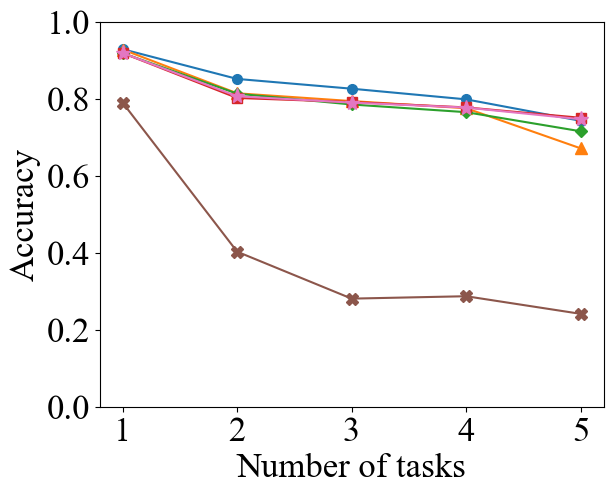

In [12]:
avg_data = list()
labels = list()

seed_range = [0, 1, 2, 3, 4]
epoch = 10
dataset = "Bios_128"
FSW_metric = "EO"

# Modifier
target_metric = "accuracy" # EO, accuracy
if save_accuracy:
    target_metric = "accuracy"
y_range = [0, 1.]
if target_metric != "accuracy":
    y_range = [0, .15]
loc = None

metric = "no_metrics"
# 0
method = "iCaRL"
lr = 0.001
tau = 1.0
alpha = 0.0
lmbd = 0.0

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, metric, target_metric))
labels.append(method)

# 1
method = "WA"
lr = 0.0001
tau = 1.0
alpha = 0.0
lmbd = 0.0

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, metric, target_metric))
labels.append(method)

# 2

method = "CLAD_1.0"
lr = 2e-5
tau = 1.0
alpha = 0.0
lmbd = 0.0

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, metric, target_metric))
labels.append(method)

# 3
method = "GSS"
lr = 2e-5
tau = 5.0
alpha = 0.0
lmbd = 0.0

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, metric, target_metric))
labels.append(method)

# # 4
# method = "OCS"
# lr = 0.01
# tau = 10.0
# alpha = 0.0
# lmbd = 0.0

# avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, metric, target_metric))
# labels.append(method)

# 5
method = "FaIRL"
lr = 2e-5
tau = 1.0
alpha = 0.0
lmbd = 0.0

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, metric, target_metric))
labels.append(method)

# 6
method = "FSW"
lr = 2e-5
tau = 5.0
alpha = 0.0005
lmbd = 1.0

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, FSW_metric, target_metric))
labels.append(method)

draw_plot(avg_data, labels, f"{dataset}({FSW_metric})", ylabel=target_metric, y_range=y_range, loc=loc)

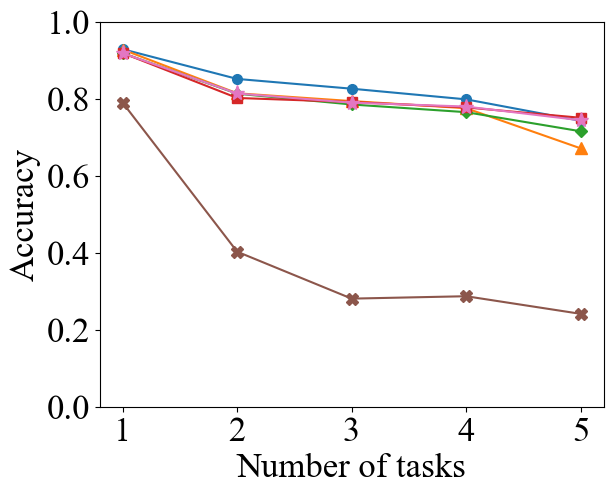

In [13]:
avg_data = list()
labels = list()

seed_range = [0, 1, 2, 3, 4]
epoch = 10
dataset = "Bios_128"
FSW_metric = "DP"

# Modifier
target_metric = "accuracy" # DP, accuracy
if save_accuracy:
    target_metric = "accuracy"
y_range = [0, 1.]
if target_metric != "accuracy":
    y_range = [0, .05]
loc = None

metric = "no_metrics"
# 0
method = "iCaRL"
lr = 0.001
tau = 1.0
alpha = 0.0
lmbd = 0.0

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, metric, target_metric))
labels.append(method)

# 1
method = "WA"
lr = 0.0001
tau = 1.0
alpha = 0.0
lmbd = 0.0

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, metric, target_metric))
labels.append(method)

method = "CLAD_1.0"
lr = 2e-5
tau = 1.0
alpha = 0.0
lmbd = 0.0

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, metric, target_metric))
labels.append(method)

# 3
method = "GSS"
lr = 2e-5
tau = 5.0
alpha = 0.0
lmbd = 0.0

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, metric, target_metric))
labels.append(method)

# # 4
# method = "OCS"
# lr = 0.01
# tau = 10.0
# alpha = 0.0
# lmbd = 0.0

# avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, metric, target_metric))
# labels.append(method)

# 5
method = "FaIRL"
lr = 2e-5
tau = 1.0
alpha = 0.0
lmbd = 0.0

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, metric, target_metric))
labels.append(method)

# 6
method = "FSW"
lr = 2e-5
tau = 10.0
alpha = 0.001
lmbd = 1.0

avg_data.append(get_avg_data(seed_range, dataset, epoch, lr, tau, alpha, lmbd, method, FSW_metric, target_metric))
labels.append(method)

draw_plot(avg_data, labels, f"{dataset}({FSW_metric})", ylabel=target_metric, y_range=y_range, loc=loc)